1. Select products from at least 5 distinct categories (e.g., electronics, clothing, books, beauty products, home goods)
2. Ensure each category has a minimum of 100 reviews
3. Create category labels based on product metadata or your own investigation
4. Implement feature engineering to extract relevant information from review text
5. Develop multiple classification approaches:
• Review-level classification: Classify each review into a product category, then use majority
voting to determine the product’s category
• Product-level classification: Aggregate all reviews for a product into a single feature
vector, then classify
6. Implement at least 3 different classification algorithms and compare their performance
7. Analyze misclassifications to identify challenging product types

In [10]:
from datasets import load_dataset, Dataset
from itertools import islice

def load_amazon_categories_streaming(categories, sample_size=3000, seed=42):
    all_data = []

    for cat in categories:
        print(f"Streaming category: {cat}...")
        try:
            stream = load_dataset(
                "McAuley-Lab/Amazon-Reviews-2023",
                f"raw_review_{cat}",
                split="full",  # <-- Corrected here
                streaming=True
            )
            sampled = list(islice(stream, sample_size))
            for r in sampled:
                r["product_category"] = cat
            all_data.extend(sampled)
        except Exception as e:
            print(f"⚠️ Failed to load category '{cat}': {e}")

    print(f"\n✅ Total collected reviews: {len(all_data)}")
    return Dataset.from_list(all_data)




In [12]:
categories = ['Electronics', 'Books', 'Home_and_Kitchen', 'All_Beauty', 'Clothing_Shoes_and_Jewelry']
combined_dataset = load_amazon_categories_streaming(categories, sample_size=5000)

Streaming category: Electronics...
Streaming category: Books...
Streaming category: Home_and_Kitchen...
Streaming category: All_Beauty...
Streaming category: Clothing_Shoes_and_Jewelry...

✅ Total collected reviews: 25000


In [ ]:
review_df = combined_dataset.to_pandas()
review_df.to_pickle("review.pkl")
review = pd.read_pickle("review.pkl")
review.head()


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,product_category
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True,Electronics
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True,Electronics
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True,Electronics
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True,Electronics
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True,Electronics


Single reviews can be noisy or sparse, so aggregating at the product level helps capture a more complete picture of a product. This is especially useful for Challenge 1, where you're trying to classify the product (not just the review) into categories.

In [2]:
import pandas as pd
review = pd.read_pickle("review.pkl")
review.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,product_category
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True,Electronics
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True,Electronics
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True,Electronics
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True,Electronics
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True,Electronics


In [3]:
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
from tqdm import tqdm

model = SentenceTransformer('all-MiniLM-L6-v2')

# Combine title + text
review['full_text'] = review['title'].fillna('') + ' ' + review['text'].fillna('')

# Encode with progress bar
tqdm.pandas()
review['embedding'] = review['full_text'].progress_apply(lambda x: model.encode(x))

100%|██████████| 25000/25000 [12:18<00:00, 33.85it/s]


In [ ]:
review.to_pickle("review.pkl")
review = pd.read_pickle("review.pkl")
review['parent_asin'].nunique()

22723

In [6]:
# Convert list-like embeddings into actual arrays for aggregation
review['embedding_array'] = review['embedding'].apply(np.array)

# Group by product (e.g., asin) and average the embeddings
product_embeddings = review.groupby('parent_asin')['embedding_array'].apply(lambda x: np.mean(x.tolist(), axis=0))

In [ ]:

# Turn the Series into a DataFrame and name the column
product_df = product_embeddings.rename('embedding').to_frame()

# Add product_category back in
product_df['product_category'] = review.drop_duplicates('parent_asin').set_index('parent_asin')['product_category']

# Reset index so you get 'parent_asin' back as a column
product_df.reset_index(inplace=True)

# Now extract features and labels
X_product = np.vstack(product_df['embedding'].values)
y_product = product_df['product_category'].values


In [ ]:
product_df.head()
product_df.to_pickle("product_df.pkl")

In [7]:
import pandas as pd
import numpy as np
product_df = pd.read_pickle('product_df.pkl')
product_df.head()

,parent_asin,embedding,product_category
0,0007176015,"[-0.08437212, 0.048469327, -0.041887764, 0.031...",Books
1,0007486774,"[-0.11107975, -0.026078232, 0.009338618, 0.038...",Books
2,0008119090,"[-0.06748395, -0.05149792, 0.011569342, 0.0136...",Books
3,0008322201,"[0.022111995, -0.10669361, -0.021940256, 0.056...",Books
4,0008390800,"[-0.024403963, -0.014026065, 0.006576489, 0.06...",Books


In [11]:
review = pd.read_pickle('review.pkl')
review.head()
review.dtypes

rating               float64
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase       bool
product_category      object
full_text             object
embedding             object
embedding_array       object
dtype: object

#### Classification

In [ ]:
# Now extract features and labels
X_product = np.vstack(product_df['embedding'].values)
y_product = product_df['product_category'].values

In [5]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, make_scorer, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Encode the labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_product)

# Split data into training and hold-out test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_product, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


In [ ]:
# Define models with pipelines where needed
models = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}


# Define metrics for cross-validation (can add more as needed)
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1_weighted': make_scorer(f1_score, average='weighted')
}

# Set up stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
cv_results = {}  # Store cross-validation results

for name, model in models.items():
    print(f"\n{name} - Cross-Validation Results:")
    
    # Perform cross-validation
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    
    # Store CV results
    cv_results[name] = {
        'mean_accuracy': np.mean(scores['test_accuracy']),
        'std_accuracy': np.std(scores['test_accuracy']),
        'mean_f1': np.mean(scores['test_f1_weighted']),
        'std_f1': np.std(scores['test_f1_weighted'])
    }
    
    # Print CV metrics
    print(f"Mean Accuracy: {cv_results[name]['mean_accuracy']:.3f} ± {cv_results[name]['std_accuracy']:.3f}")
    print(f"Mean F1 (weighted): {cv_results[name]['mean_f1']:.3f} ± {cv_results[name]['std_f1']:.3f}")
    
    # Train on full training set and evaluate on test set
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Store and print classification report
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)
    results[name] = report
    print(f"\n{name} - Test Set Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Optional: Print summary of CV results
print("\n=== Cross-Validation Summary ===")
for name, metrics in cv_results.items():
    print(f"{name}:")
    print(f"  Accuracy: {metrics['mean_accuracy']:.3f} ± {metrics['std_accuracy']:.3f}")
    print(f"  F1 (weighted): {metrics['mean_f1']:.3f} ± {metrics['std_f1']:.3f}\n")


KNN - Cross-Validation Results:
Mean Accuracy: 0.825 ± 0.007
Mean F1 (weighted): 0.825 ± 0.007

KNN - Test Set Classification Report:

                            precision    recall  f1-score   support

                All_Beauty       0.69      0.88      0.77       744
                     Books       0.95      0.92      0.93       979
Clothing_Shoes_and_Jewelry       0.85      0.87      0.86       961
               Electronics       0.82      0.86      0.84       902
          Home_and_Kitchen       0.89      0.67      0.76       959

                  accuracy                           0.84      4545
                 macro avg       0.84      0.84      0.83      4545
              weighted avg       0.85      0.84      0.84      4545


'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(random_state=42))
    ]),
    Logistic Regression - Cross-Validation Results:
Mean Accuracy: 0.843 ± 0.007
Mean F1 (weighted): 0.843 ± 0.007

'SVM': Pipeline([
        ('sc

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2', 'elasticnet'],
    'model__solver': ['saga']  # supports all penalties
}

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)

d:\miniconda\envs\data_engineering\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "d:\miniconda\envs\data_engineering\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\miniconda\envs\data_engineering\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\miniconda\envs\data_engineering\Lib\site-packages\sklearn\pipeline.py", line 6

Best params: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'saga'}


In [32]:
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        C=0.01,
        penalty='l2',
        solver='saga',
        max_iter=5000,
        random_state=42
    ))
])
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82       744
           1       0.94      0.95      0.94       979
           2       0.86      0.85      0.86       961
           3       0.84      0.86      0.85       902
           4       0.79      0.79      0.79       959

    accuracy                           0.85      4545
   macro avg       0.85      0.85      0.85      4545
weighted avg       0.85      0.85      0.85      4545



In [6]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Individual models
logistic_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        C=0.01, 
        penalty='l2',
        solver='saga',
        max_iter=5000,
        random_state=42
    ))
])

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    min_samples_leaf=3,
    random_state=42
)

# Soft Voting Ensemble (uses class probabilities)
ensemble = VotingClassifier(
    estimators=[
        ('logistic', logistic_pipe),
        ('random_forest', rf_model)
    ],
    voting='soft',  # 'soft' often works better than 'hard'
    n_jobs=-1
)
# Train
ensemble.fit(X_train, y_train)

# Evaluate
y_pred = ensemble.predict(X_test)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Cross-validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(ensemble, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

                            precision    recall  f1-score   support

                All_Beauty       0.85      0.80      0.82       744
                     Books       0.94      0.95      0.94       979
Clothing_Shoes_and_Jewelry       0.86      0.86      0.86       961
               Electronics       0.83      0.86      0.85       902
          Home_and_Kitchen       0.79      0.80      0.79       959

                  accuracy                           0.85      4545
                 macro avg       0.85      0.85      0.85      4545
              weighted avg       0.85      0.85      0.85      4545

CV Accuracy: 0.851 ± 0.004


In [8]:
np.bincount(y_encoded)


array([3719, 4894, 4804, 4509, 4797])

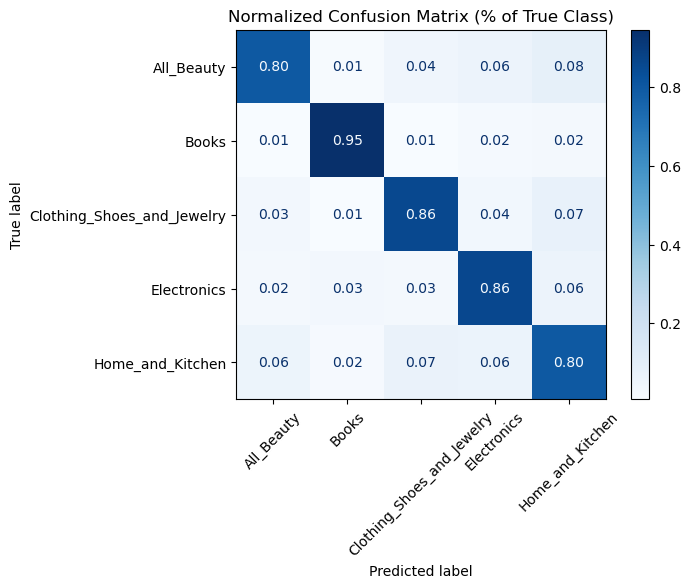

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

# Normalized confusion matrix (percentages)
disp = ConfusionMatrixDisplay.from_estimator(
    ensemble,
    X_test, 
    y_test,
    display_labels=label_encoder.classes_,
    cmap='Blues',
    normalize='true',  # Normalize by row (true classes)
    values_format='.2f'  # Show percentages
)
plt.title('Normalized Confusion Matrix (% of True Class)')
plt.xticks(rotation=45)  # Rotate labels if needed
plt.show()

In [15]:
import pandas as pd

# Create a DataFrame of errors
errors = pd.DataFrame({
    'True': label_encoder.inverse_transform(y_test),
    'Predicted': label_encoder.inverse_transform(y_pred),
    'Features': [str(x) for x in X_test]  # Optional: Include raw features
})
misclassified = errors[errors['True'] != errors['Predicted']]
print(f"\nMisclassified Samples ({len(misclassified)}/{len(y_test)}):")
print(misclassified.head())


Misclassified Samples (660/4545):
                          True         Predicted  \
2                        Books  Home_and_Kitchen   
13                  All_Beauty  Home_and_Kitchen   
19  Clothing_Shoes_and_Jewelry       Electronics   
31                  All_Beauty  Home_and_Kitchen   
36                  All_Beauty       Electronics   

                                             Features  
2   [ 5.41365184e-02  5.36106676e-02 -1.77736506e-...  
13  [ 2.48523336e-03 -6.06542192e-02  1.83322966e-...  
19  [ 1.98473111e-02  5.61787859e-02 -1.16717041e-...  
31  [-8.50207079e-03  7.01859668e-02  2.78207697e-...  
36  [-8.68503153e-02  2.45761182e-02 -1.64552312e-...  


In [16]:
# For multiclass: Plot most confused pairs
confused_pairs = cm.copy()
np.fill_diagonal(confused_pairs, 0)  # Ignore correct predictions
top_errors = np.unravel_index(np.argmax(confused_pairs), confused_pairs.shape)

print(f"\nMost Common Error: True '{label_encoder.classes_[top_errors[0]]}'")
print(f"Misclassified as '{label_encoder.classes_[top_errors[1]]}' ({confused_pairs[top_errors]} cases)")


Most Common Error: True 'Clothing_Shoes_and_Jewelry'
Misclassified as 'Home_and_Kitchen' (70 cases)


In [17]:
import pandas as pd

# Decode labels back to original categories
y_test_decoded = label_encoder.inverse_transform(y_test)
y_pred_decoded = label_encoder.inverse_transform(y_pred)

# Create a DataFrame of misclassified samples
misclassified = pd.DataFrame({
    'True_Product': y_test_decoded,
    'Predicted_Product': y_pred_decoded,
    'Features': list(X_test)  # Optional: Include feature values
})

# Filter only incorrect predictions
misclassified = misclassified[y_test_decoded != y_pred_decoded]
print(f"Total Misclassifications: {len(misclassified)}/{len(y_test)}")

Total Misclassifications: 660/4545


In [20]:
from collections import defaultdict

misclassification_pairs = defaultdict(int)
for true, pred in zip(y_test_decoded, y_pred_decoded):
    if true != pred:
        misclassification_pairs[(true, pred)] += 1

# Top 5 most frequent misclassifications
top_pairs = sorted(misclassification_pairs.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop Misclassification Pairs:")
for (true, pred), count in top_pairs:
    print(f"True: {true} → Predicted: {pred} ({count} cases)")


Top Misclassification Pairs:
True: Clothing_Shoes_and_Jewelry → Predicted: Home_and_Kitchen (70 cases)
True: Home_and_Kitchen → Predicted: Clothing_Shoes_and_Jewelry (65 cases)
True: All_Beauty → Predicted: Home_and_Kitchen (63 cases)
True: Home_and_Kitchen → Predicted: Electronics (59 cases)
True: Home_and_Kitchen → Predicted: All_Beauty (54 cases)


#### visual representation

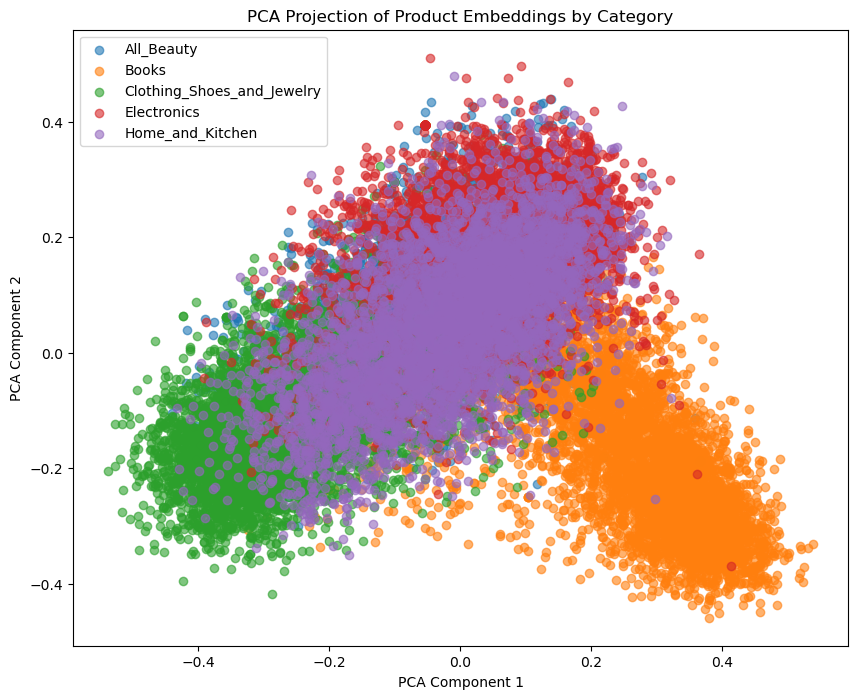

In [29]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Assume X_product is your 2D array of product-level embeddings
# and y_encoded contains the numeric labels (from LabelEncoder)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_product)

plt.figure(figsize=(10, 8))
for category in np.unique(y_encoded):
    idx = y_encoded == category
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], 
                label=label_encoder.inverse_transform([category])[0], alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title("PCA Projection of Product Embeddings by Category")
plt.legend()
plt.show()


This plot lets you see how well the embeddings separate the different categories. If the clusters are well separated, it means the features you’re using are capturing important distinctions between the product groups.

2. Recommendations for Improving the Product Categorization System
When writing up your recommendations for Challenge 1, consider these key points:

Enhance Feature Engineering:

Fine-Tune the Embedding Model:
The current transformer model (e.g., all-MiniLM-L6-v2) was trained on general text. Fine-tuning it on your domain-specific data (Amazon reviews for electronics, fashion, etc.) may produce embeddings that are more discriminative for your categories.

Combine Multiple Feature Types:
Consider integrating other sources of information. For instance, combining your transformer-based embeddings with traditional methods like TF-IDF vectors or incorporating metadata (such as review length, verified purchase status, etc.) might capture complementary aspects that improve classification.

Interpretability of the Classifier:

Visualization via Dimensionality Reduction:
As shown above, use PCA/t-SNE/UMAP to visually inspect how different categories cluster. This not only helps in validating the quality of the embeddings but also provides an intuitive explanation for business stakeholders.

Post-hoc Explanations:
Apply interpretation methods (like SHAP or LIME) on your ensemble classifiers to determine which features (or which aspects of the embedding space) most influence category predictions. This can provide insight into the critical review elements that distinguish each category.

Model Ensemble and Continuous Improvement:

Ensemble Methods:
You are already leveraging an ensemble (VotingClassifier) of Logistic Regression and Random Forest. Further experimentation with additional models (or fine-tuning ensemble weights) might boost performance.

Iterative Feedback:
Develop mechanisms where misclassified products can be manually reviewed and then used to refine the categorization rules or further train the model. This feedback loop can improve performance over time and help uncover edge cases.

Operational Considerations:

Deployment and Scalability:
Evaluate how the model can be integrated into the product workflow. For example, automatically flagging products that are likely miscategorized can lead to targeted manual reviews, improving the overall categorization quality.

Monitoring and Maintenance:
Set up a monitoring dashboard that tracks classification accuracy, the distribution of predicted categories, and alert thresholds. This will help maintain system performance and quickly catch any degradation when new data is introduced.

Summary
Visual Representation:
Use techniques like PCA to project your high-dimensional product embeddings into a 2D plot and identify distinct clusters corresponding to each product category.

Recommendations:
Focus on enhancing feature engineering (through fine-tuning and combining feature types), ensuring model interpretability (using SHAP/LIME and visualizations), improving operational deployment (via feedback mechanisms), and continuously monitoring model performance.
